In [1]:
import matplotlib.pyplot as plt
import torch

from numb_project.data_module import MnistDataModule, rotate_item

data_module = MnistDataModule(batch_size=16)
test_loader = data_module.test_dataloader()

# Récupère un batch contenant la clé "image"
batch, batch_idx, dataloader_idx = next(iter(test_loader))

image_batch = None
for value in batch.values():
    if "image" in value:
        image_batch = value["image"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'image'")

image_batch.shape

/home/lucasc/.cache/pypoetry/virtualenvs/gwnumb-MdIKXIiF-py3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


torch.Size([16, 1, 28, 28])

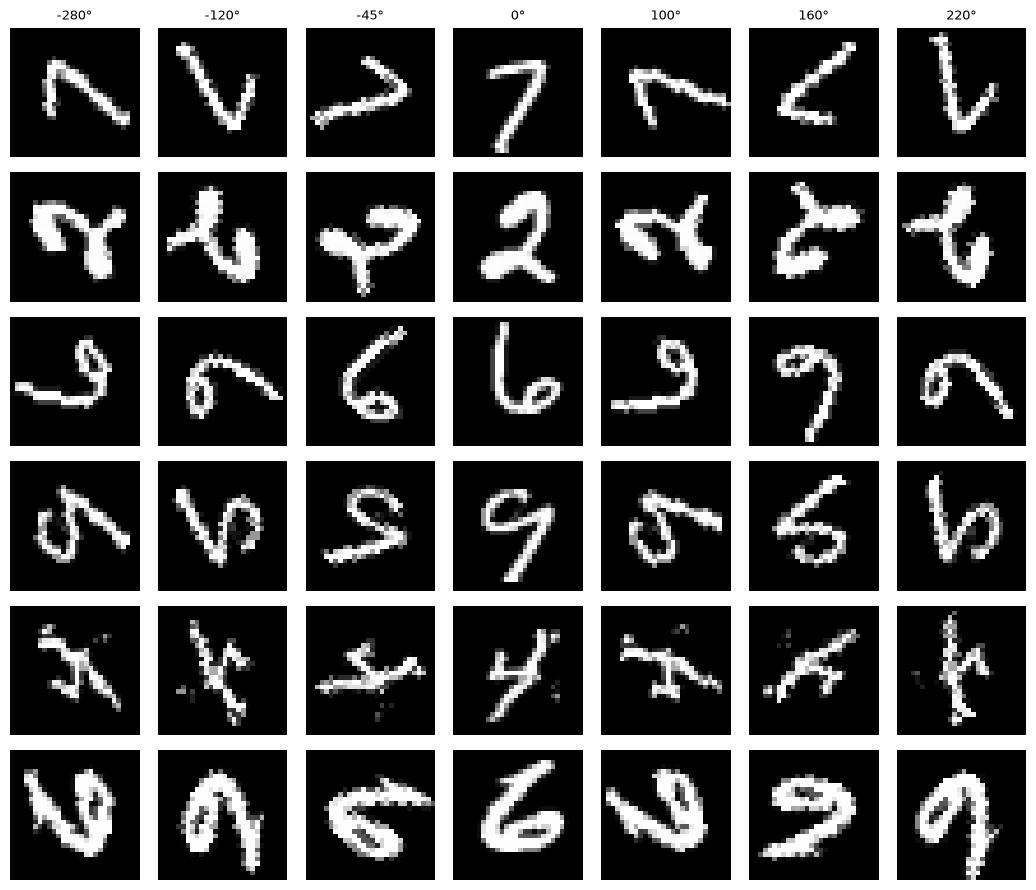

In [2]:
n_examples = 6
angles = [-280, -120, -45, 0, 100, 160 , 220]

images = image_batch[:n_examples]

fig, axes = plt.subplots(n_examples, len(angles), figsize=(len(angles) * 1.5, n_examples * 1.5))

for row in range(n_examples):
    for col, degrees in enumerate(angles):
        item = {"image": images[row : row + 1]}
        rotated = rotate_item(item, degrees)["image"][0]

        ax = axes[row, col]
        ax.imshow(rotated[0].numpy(), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{degrees}°", fontsize=9)

plt.tight_layout()
plt.show()

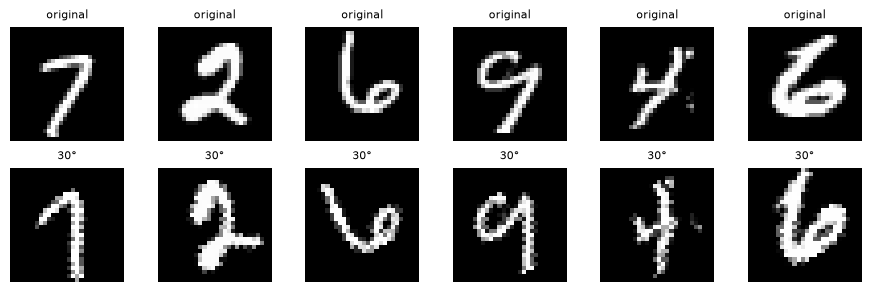

In [3]:
# Rotation batchée : rotate_item accepte directement un batch d'images
degrees = 30
rotated_batch = rotate_item({"image": images}, degrees)["image"]

fig, axes = plt.subplots(2, n_examples, figsize=(n_examples * 1.5, 3))
for i in range(n_examples):
    axes[0, i].imshow(images[i, 0].numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(rotated_batch[i, 0].numpy(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"{degrees}°", fontsize=8)

plt.tight_layout()
plt.show()